In [8]:
import os
import random
import requests
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from PIL import Image
from io import BytesIO

import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import layers

from sklearn.model_selection import train_test_split
from sklearn.metrics import (
    classification_report,
    confusion_matrix,
    accuracy_score
)

print("TensorFlow version:", tf.__version__)

TensorFlow version: 2.21.0


In [9]:
metadata_path = "metadata.csv"

df = pd.read_csv("Data/metadata.csv")

print("Dataset shape:", df.shape)
print("\nColumns:")
print(df.columns.tolist())

df.head()

Dataset shape: (2084, 9)

Columns:
['class', 'filename', 'title', 'creator', 'license', 'license_version', 'source', 'foreign_landing_url', 'original_url']


,class,filename,title,creator,license,license_version,source,foreign_landing_url,original_url
0,BMW_M3,0000.jpg,BMW M3 E46 + E34,raito.akehanareru,by-sa,2.0,flickr,https://www.flickr.com/photos/109740338@N03/15...,https://live.staticflickr.com/7567/15621402140...
1,BMW_M3,0001.jpg,2001 BMW M3,The Pug Father,by,2.0,flickr,https://www.flickr.com/photos/76929828@N00/250...,https://live.staticflickr.com/3106/2504408734_...
2,BMW_M3,0002.jpg,BMW M3 E46,raito.akehanareru,by-sa,2.0,flickr,https://www.flickr.com/photos/109740338@N03/15...,https://live.staticflickr.com/5608/15804362901...
3,BMW_M3,0003.jpg,BMW M3 E46,raito.akehanareru,by-sa,2.0,flickr,https://www.flickr.com/photos/109740338@N03/15...,https://live.staticflickr.com/8578/15620427719...
4,BMW_M3,0004.jpg,BMW M3 E46,raito.akehanareru,by-sa,2.0,flickr,https://www.flickr.com/photos/109740338@N03/15...,https://live.staticflickr.com/7495/15806254535...


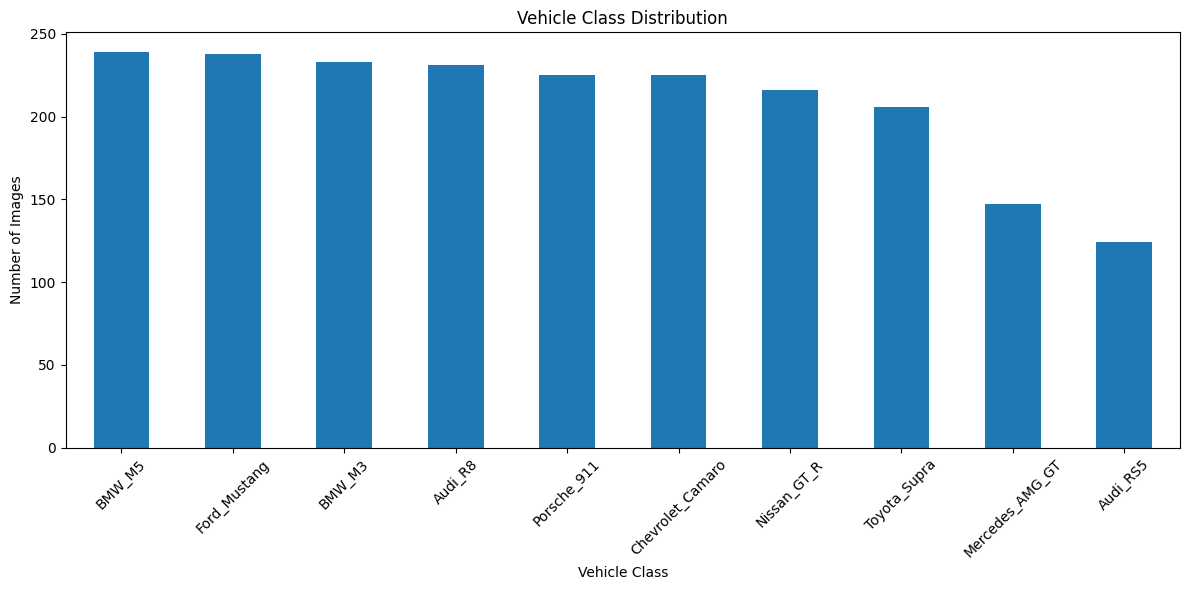

In [10]:
plt.figure(figsize=(12, 6))

df["class"].value_counts().plot(kind="bar")

plt.title("Vehicle Class Distribution")
plt.xlabel("Vehicle Class")
plt.ylabel("Number of Images")
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

In [4]:
BASE_DIR = "dataset"

os.makedirs(BASE_DIR, exist_ok=True)

for vehicle_class in df["class"].unique():
    os.makedirs(
        os.path.join(BASE_DIR, vehicle_class),
        exist_ok=True
    )

print("Class folders created.")

Class folders created.


In [5]:
def download_image(url, save_path):
    try:
        response = requests.get(
            url,
            timeout=20,
            headers={
                "User-Agent": "Mozilla/5.0"
            }
        )

        if response.status_code == 200:
            image = Image.open(BytesIO(response.content))
            image = image.convert("RGB")
            image.save(save_path, format="JPEG")
            return True

    except Exception as e:
        return False

    return False

In [6]:
successful = 0
failed = 0

for index, row in df.iterrows():

    vehicle_class = row["class"]
    filename = row["filename"]
    url = row["original_url"]

    save_path = os.path.join(
        BASE_DIR,
        vehicle_class,
        filename
    )

    if os.path.exists(save_path):
        successful += 1
        continue

    result = download_image(url, save_path)

    if result:
        successful += 1
    else:
        failed += 1

    if (index + 1) % 100 == 0:
        print(
            f"Processed: {index + 1}/{len(df)}"
        )

print("\nDownload completed.")
print("Successful:", successful)
print("Failed:", failed)

Processed: 200/2084
Processed: 300/2084
Processed: 400/2084
Processed: 500/2084
Processed: 600/2084
Processed: 700/2084
Processed: 800/2084
Processed: 900/2084
Processed: 1000/2084
Processed: 1100/2084
Processed: 1200/2084
Processed: 1300/2084
Processed: 1400/2084
Processed: 1500/2084
Processed: 1600/2084
Processed: 1700/2084
Processed: 1800/2084
Processed: 1900/2084
Processed: 2000/2084

Download completed.
Successful: 2084
Failed: 0


In [12]:
def count_images(folder):
    total = 0

    for root, dirs, files in os.walk(folder):
        for file in files:
            if file.lower().endswith(
                (".jpg", ".jpeg", ".png")
            ):
                total += 1

    return total


total_images = count_images(BASE_DIR)

print("Total downloaded images:", total_images)

Total downloaded images: 2084


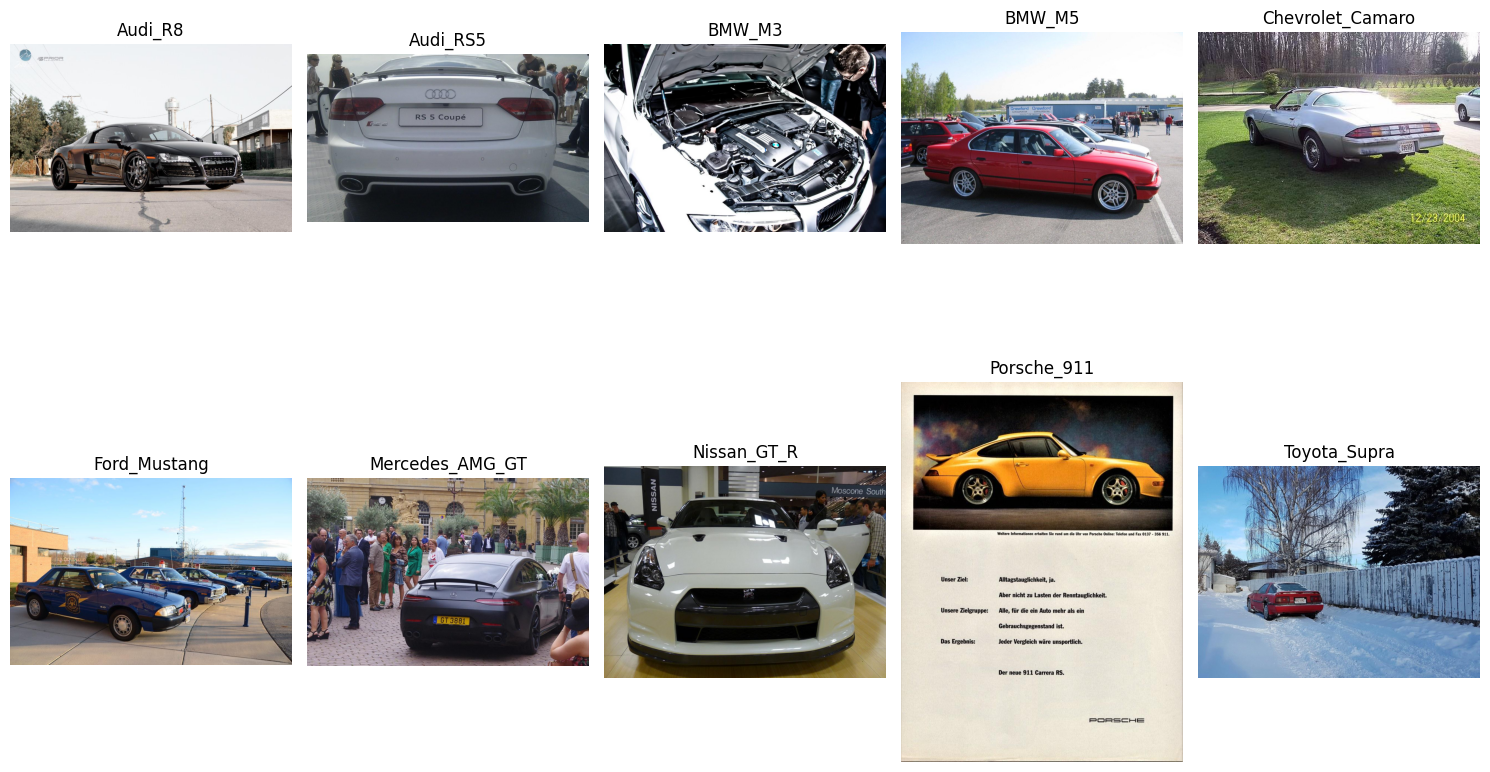

In [13]:
classes = sorted(
    [
        folder for folder in os.listdir(BASE_DIR)
        if os.path.isdir(os.path.join(BASE_DIR, folder))
    ]
)

plt.figure(figsize=(15, 10))

for i, vehicle_class in enumerate(classes):

    class_folder = os.path.join(
        BASE_DIR,
        vehicle_class
    )

    images = [
        f for f in os.listdir(class_folder)
        if f.lower().endswith(
            (".jpg", ".jpeg", ".png")
        )
    ]

    if len(images) == 0:
        continue

    image_path = os.path.join(
        class_folder,
        random.choice(images)
    )

    image = Image.open(image_path)

    plt.subplot(2, 5, i + 1)
    plt.imshow(image)
    plt.title(vehicle_class)
    plt.axis("off")

plt.tight_layout()
plt.show()

In [14]:
image_paths = []
labels = []

for vehicle_class in classes:

    class_folder = os.path.join(
        BASE_DIR,
        vehicle_class
    )

    for filename in os.listdir(class_folder):

        if filename.lower().endswith(
            (".jpg", ".jpeg", ".png")
        ):

            image_paths.append(
                os.path.join(
                    class_folder,
                    filename
                )
            )

            labels.append(vehicle_class)

data = pd.DataFrame({
    "image_path": image_paths,
    "class": labels
})

print(data.shape)
data.head()

(2084, 2)


,image_path,class
0,dataset\Audi_R8\0000.jpg,Audi_R8
1,dataset\Audi_R8\0001.jpg,Audi_R8
2,dataset\Audi_R8\0002.jpg,Audi_R8
3,dataset\Audi_R8\0003.jpg,Audi_R8
4,dataset\Audi_R8\0004.jpg,Audi_R8


In [15]:
train_df, temp_df = train_test_split(
    data,
    test_size=0.30,
    stratify=data["class"],
    random_state=42
)

val_df, test_df = train_test_split(
    temp_df,
    test_size=0.50,
    stratify=temp_df["class"],
    random_state=42
)

print("Training:", len(train_df))
print("Validation:", len(val_df))
print("Testing:", len(test_df))

Training: 1458
Validation: 313
Testing: 313


In [16]:
class_names = sorted(data["class"].unique())

class_to_index = {
    name: i
    for i, name in enumerate(class_names)
}

index_to_class = {
    i: name
    for name, i in class_to_index.items()
}

print(class_to_index)

{'Audi_R8': 0, 'Audi_RS5': 1, 'BMW_M3': 2, 'BMW_M5': 3, 'Chevrolet_Camaro': 4, 'Ford_Mustang': 5, 'Mercedes_AMG_GT': 6, 'Nissan_GT_R': 7, 'Porsche_911': 8, 'Toyota_Supra': 9}


In [17]:
train_df["label"] = train_df["class"].map(class_to_index)
val_df["label"] = val_df["class"].map(class_to_index)
test_df["label"] = test_df["class"].map(class_to_index)

In [18]:
IMG_SIZE = (128, 128)
BATCH_SIZE = 32
NUM_CLASSES = len(class_names)

print("Number of classes:", NUM_CLASSES)
print("Image size:", IMG_SIZE)

Number of classes: 10
Image size: (128, 128)


In [19]:
def create_dataset(dataframe, shuffle=False):

    paths = dataframe["image_path"].values
    labels = dataframe["label"].values

    dataset = tf.data.Dataset.from_tensor_slices(
        (paths, labels)
    )

    def load_image(path, label):

        image = tf.io.read_file(path)

        image = tf.image.decode_jpeg(
            image,
            channels=3
        )

        image = tf.image.resize(
            image,
            IMG_SIZE
        )

        image = tf.cast(
            image,
            tf.float32
        )

        return image, label

    dataset = dataset.map(
        load_image,
        num_parallel_calls=tf.data.AUTOTUNE
    )

    if shuffle:
        dataset = dataset.shuffle(
            1000,
            seed=42
        )

    dataset = dataset.batch(BATCH_SIZE)
    dataset = dataset.prefetch(
        tf.data.AUTOTUNE
    )

    return dataset

In [20]:
train_dataset = create_dataset(
    train_df,
    shuffle=True
)

val_dataset = create_dataset(
    val_df
)

test_dataset = create_dataset(
    test_df
)

In [21]:
data_augmentation = keras.Sequential([
    
    layers.RandomFlip(
        "horizontal"
    ),
    
    layers.RandomRotation(
        0.10
    ),
    
    layers.RandomZoom(
        0.15
    ),
    
    layers.RandomTranslation(
        height_factor=0.10,
        width_factor=0.10
    ),
    
    layers.RandomContrast(
        0.10
    )
    
], name="data_augmentation")

In [22]:
model = keras.Sequential([

    layers.Input(
        shape=(128, 128, 3)
    ),

    # Data augmentation
    data_augmentation,

    # Normalization
    layers.Rescaling(
        1.0 / 255
    ),

    # CNN Block 1
    layers.Conv2D(
        32,
        (3, 3),
        padding="same",
        activation="relu"
    ),

    layers.BatchNormalization(),

    layers.MaxPooling2D(
        (2, 2)
    ),

    # CNN Block 2
    layers.Conv2D(
        64,
        (3, 3),
        padding="same",
        activation="relu"
    ),

    layers.BatchNormalization(),

    layers.MaxPooling2D(
        (2, 2)
    ),

    # CNN Block 3
    layers.Conv2D(
        128,
        (3, 3),
        padding="same",
        activation="relu"
    ),

    layers.BatchNormalization(),

    layers.MaxPooling2D(
        (2, 2)
    ),

    # CNN Block 4
    layers.Conv2D(
        256,
        (3, 3),
        padding="same",
        activation="relu"
    ),

    layers.BatchNormalization(),

    layers.MaxPooling2D(
        (2, 2)
    ),

    # Feature extraction
    layers.Flatten(),

    # Fully connected layer
    layers.Dense(
        128,
        activation="relu"
    ),

    # Dropout
    layers.Dropout(
        0.5
    ),

    # Output
    layers.Dense(
        NUM_CLASSES,
        activation="softmax"
    )
])

model.summary()

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ data_augmentation (Sequential)  │ (None, 128, 128, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ rescaling (Rescaling)           │ (None, 128, 128, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d (Conv2D)                 │ (None, 128, 128, 32)   │           896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization             │ (None, 128, 128, 32)   │           128 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d (MaxPooling2D)    │ (None, 64, 64, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_1 (Conv2D)               │ (None, 64, 64, 64)     │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_1           │ (None, 64, 64, 64)     │           256 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_1 (MaxPooling2D)  │ (None, 32, 32, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_2 (Conv2D)               │ (None, 32, 32, 128)    │        73,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_2           │ (None, 32, 32, 128)    │           512 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_2 (MaxPooling2D)  │ (None, 16, 16, 128)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_3 (Conv2D)               │ (None, 16, 16, 256)    │       295,168 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_3           │ (None, 16, 16, 256)    │         1,024 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_3 (MaxPooling2D)  │ (None, 8, 8, 256)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten (Flatten)               │ (None, 16384)          │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 128)            │     2,097,280 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 10)             │         1,290 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 2,488,906 (9.49 MB)

 Trainable params: 2,487,946 (9.49 MB)

 Non-trainable params: 960 (3.75 KB)

In [23]:
optimizer = keras.optimizers.Adam(
    learning_rate=0.001
)

model.compile(
    optimizer=optimizer,
    loss="sparse_categorical_crossentropy",
    metrics=["accuracy"]
)

In [24]:
callbacks = [

    keras.callbacks.EarlyStopping(
        monitor="val_loss",
        patience=7,
        restore_best_weights=True
    ),

    keras.callbacks.ReduceLROnPlateau(
        monitor="val_loss",
        factor=0.5,
        patience=3,
        min_lr=1e-7
    ),

    keras.callbacks.ModelCheckpoint(
        "best_vehicle_cnn.keras",
        monitor="val_accuracy",
        save_best_only=True
    )
]

In [25]:
EPOCHS = 30

history = model.fit(
    train_dataset,
    validation_data=val_dataset,
    epochs=EPOCHS,
    callbacks=callbacks
)

Epoch 1/30


C:\Users\dell\AppData\Roaming\Python\Python313\site-packages\keras\src\trainers\epoch_iterator.py:74: UserWarning: `shuffle=True` was passed, but will be ignored since the data `x` was provided as a tf.data.Dataset. The Dataset is expected to already be shuffled (via `.shuffle(buffer_size)`).
  self.data_adapter = data_adapters.get_data_adapter(


46/46 ━━━━━━━━━━━━━━━━━━━━ 34s 607ms/step - accuracy: 0.1139 - loss: 3.2684 - val_accuracy: 0.1022 - val_loss: 2.8603 - learning_rate: 0.0010
Epoch 2/30
46/46 ━━━━━━━━━━━━━━━━━━━━ 31s 664ms/step - accuracy: 0.1187 - loss: 2.3230 - val_accuracy: 0.0831 - val_loss: 2.3188 - learning_rate: 0.0010
Epoch 3/30
46/46 ━━━━━━━━━━━━━━━━━━━━ 43s 896ms/step - accuracy: 0.1139 - loss: 2.3031 - val_accuracy: 0.1246 - val_loss: 2.2957 - learning_rate: 0.0010
Epoch 4/30
46/46 ━━━━━━━━━━━━━━━━━━━━ 42s 879ms/step - accuracy: 0.1145 - loss: 2.2970 - val_accuracy: 0.1150 - val_loss: 2.2914 - learning_rate: 0.0010
Epoch 5/30
46/46 ━━━━━━━━━━━━━━━━━━━━ 42s 883ms/step - accuracy: 0.1145 - loss: 2.2951 - val_accuracy: 0.1214 - val_loss: 2.2911 - learning_rate: 0.0010
Epoch 6/30
46/46 ━━━━━━━━━━━━━━━━━━━━ 43s 883ms/step - accuracy: 0.1145 - loss: 2.2936 - val_accuracy: 0.1246 - val_loss: 2.2801 - learning_rate: 0.0010
Epoch 7/30
46/46 ━━━━━━━━━━━━━━━━━━━━ 45s 934ms/step - accuracy: 0.1145 - loss: 2.2923 - val_

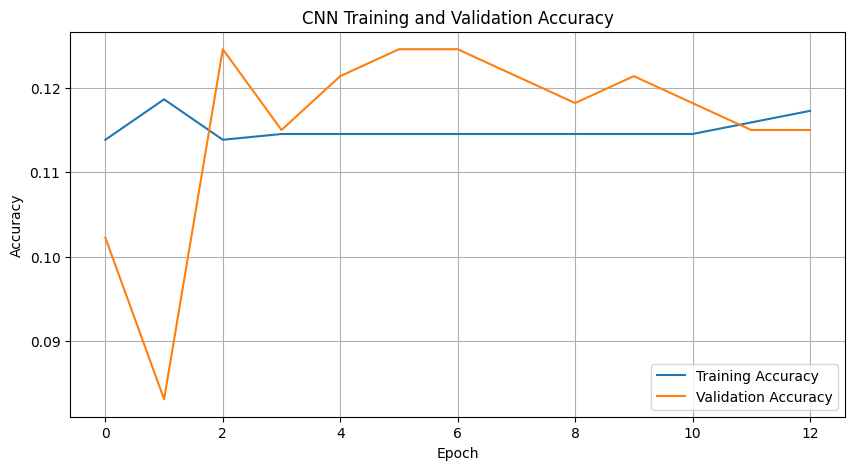

In [26]:
plt.figure(figsize=(10, 5))

plt.plot(
    history.history["accuracy"],
    label="Training Accuracy"
)

plt.plot(
    history.history["val_accuracy"],
    label="Validation Accuracy"
)

plt.title("CNN Training and Validation Accuracy")
plt.xlabel("Epoch")
plt.ylabel("Accuracy")
plt.legend()
plt.grid()

plt.show()

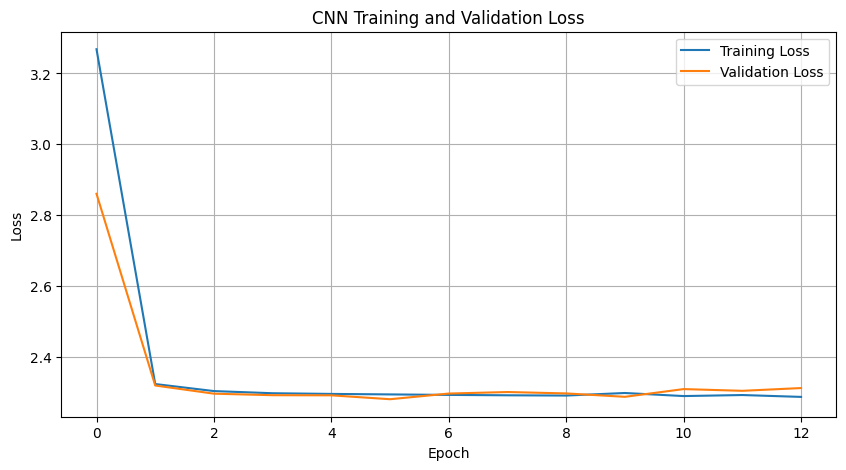

In [27]:
plt.figure(figsize=(10, 5))

plt.plot(
    history.history["loss"],
    label="Training Loss"
)

plt.plot(
    history.history["val_loss"],
    label="Validation Loss"
)

plt.title("CNN Training and Validation Loss")
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.legend()
plt.grid()

plt.show()

In [28]:
test_loss, test_accuracy = model.evaluate(
    test_dataset
)

print("Test Loss:", test_loss)
print("Test Accuracy:", test_accuracy)

10/10 ━━━━━━━━━━━━━━━━━━━━ 2s 227ms/step - accuracy: 0.1150 - loss: 2.2945
Test Loss: 2.2945475578308105
Test Accuracy: 0.11501597613096237


In [29]:
y_true = []
y_pred = []

for images, labels in test_dataset:

    predictions = model.predict(
        images,
        verbose=0
    )

    predicted_labels = np.argmax(
        predictions,
        axis=1
    )

    y_true.extend(
        labels.numpy()
    )

    y_pred.extend(
        predicted_labels
    )

y_true = np.array(y_true)
y_pred = np.array(y_pred)

In [30]:
report = classification_report(
    y_true,
    y_pred,
    target_names=class_names
)

print(report)

                  precision    recall  f1-score   support

         Audi_R8       0.00      0.00      0.00        35
        Audi_RS5       0.00      0.00      0.00        18
          BMW_M3       0.00      0.00      0.00        35
          BMW_M5       0.12      1.00      0.21        36
Chevrolet_Camaro       0.00      0.00      0.00        34
    Ford_Mustang       0.00      0.00      0.00        36
 Mercedes_AMG_GT       0.00      0.00      0.00        22
     Nissan_GT_R       0.00      0.00      0.00        32
     Porsche_911       0.00      0.00      0.00        34
    Toyota_Supra       0.00      0.00      0.00        31

        accuracy                           0.12       313
       macro avg       0.01      0.10      0.02       313
    weighted avg       0.01      0.12      0.02       313



C:\Users\dell\AppData\Roaming\Python\Python313\site-packages\sklearn\metrics\_classification.py:1879: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
C:\Users\dell\AppData\Roaming\Python\Python313\site-packages\sklearn\metrics\_classification.py:1879: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
C:\Users\dell\AppData\Roaming\Python\Python313\site-packages\sklearn\metrics\_classification.py:1879: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize

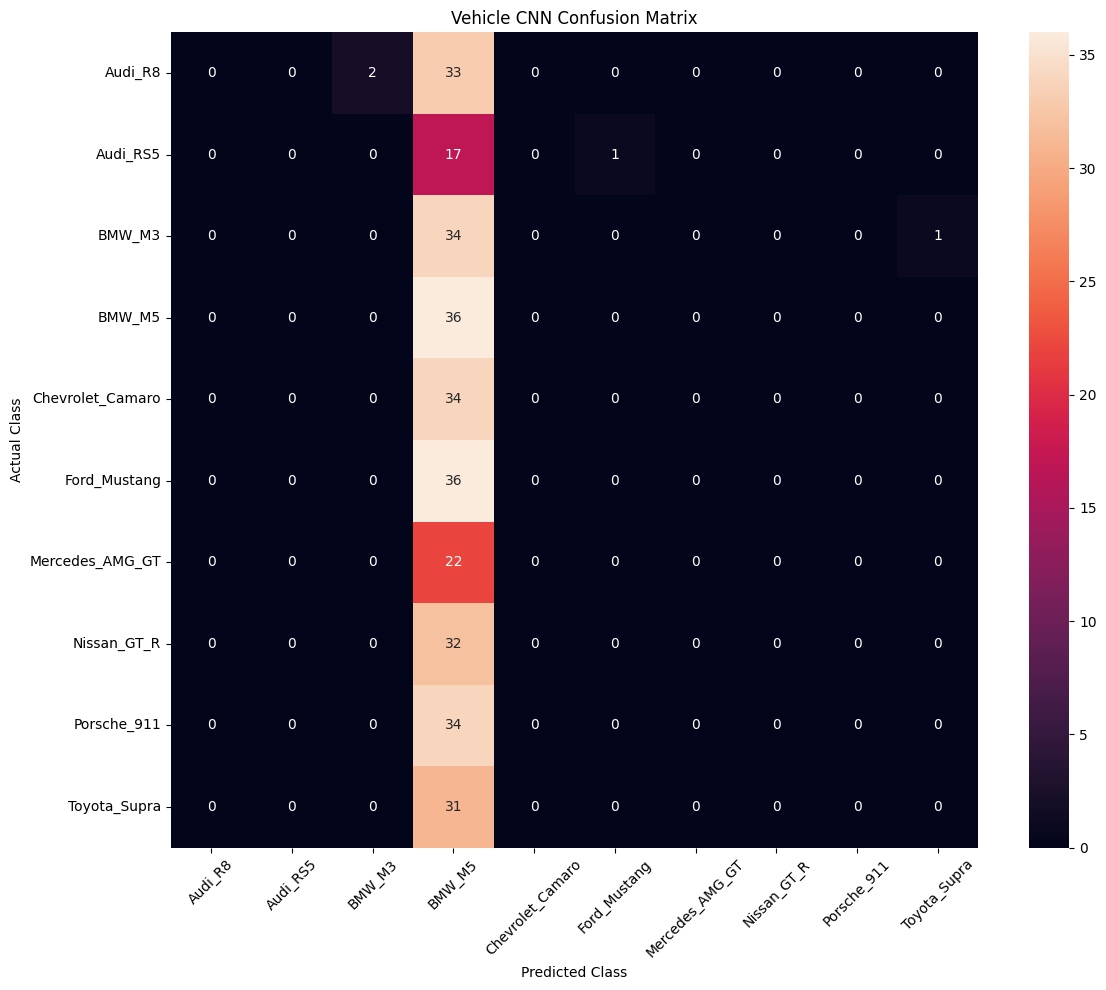

In [31]:
cm = confusion_matrix(
    y_true,
    y_pred
)

plt.figure(figsize=(12, 10))

sns.heatmap(
    cm,
    annot=True,
    fmt="d",
    xticklabels=class_names,
    yticklabels=class_names
)

plt.xlabel("Predicted Class")
plt.ylabel("Actual Class")
plt.title("Vehicle CNN Confusion Matrix")

plt.xticks(rotation=45)
plt.yticks(rotation=0)

plt.tight_layout()
plt.show()

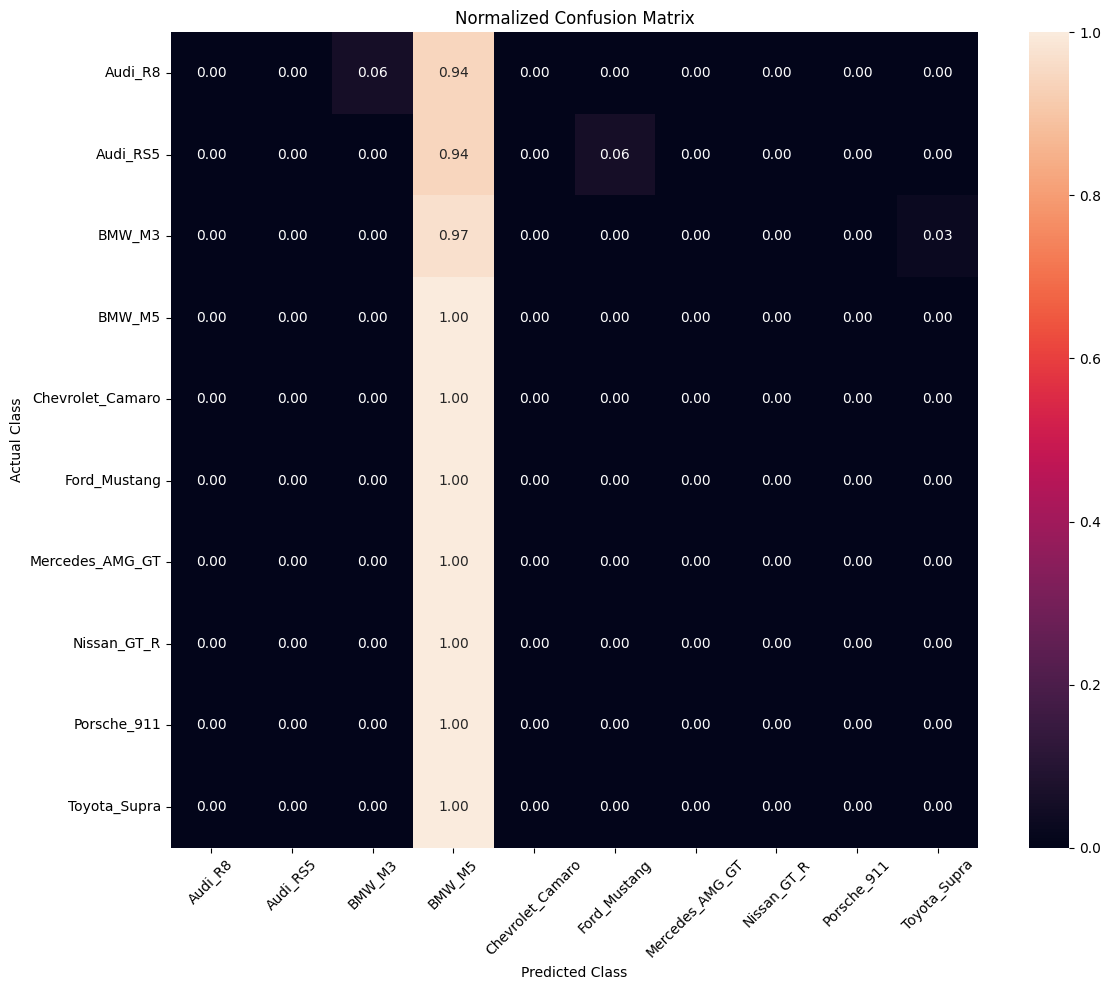

In [32]:
cm_normalized = cm.astype("float") / cm.sum(
    axis=1
)[:, np.newaxis]

plt.figure(figsize=(12, 10))

sns.heatmap(
    cm_normalized,
    annot=True,
    fmt=".2f",
    xticklabels=class_names,
    yticklabels=class_names
)

plt.xlabel("Predicted Class")
plt.ylabel("Actual Class")
plt.title("Normalized Confusion Matrix")

plt.xticks(rotation=45)
plt.yticks(rotation=0)

plt.tight_layout()
plt.show()

In [33]:
optimizers = {

    "SGD": keras.optimizers.SGD(
        learning_rate=0.001
    ),

    "Momentum": keras.optimizers.SGD(
        learning_rate=0.001,
        momentum=0.9
    ),

    "RMSprop": keras.optimizers.RMSprop(
        learning_rate=0.001
    ),

    "Adam": keras.optimizers.Adam(
        learning_rate=0.001
    )
}

In [34]:
def build_cnn(
    filters=32,
    dense_units=128,
    dropout_rate=0.5
):

    model = keras.Sequential([

        layers.Input(
            shape=(128, 128, 3)
        ),

        data_augmentation,

        layers.Rescaling(
            1./255
        ),

        layers.Conv2D(
            filters,
            3,
            padding="same",
            activation="relu"
        ),

        layers.BatchNormalization(),

        layers.MaxPooling2D(),

        layers.Conv2D(
            filters * 2,
            3,
            padding="same",
            activation="relu"
        ),

        layers.BatchNormalization(),

        layers.MaxPooling2D(),

        layers.Conv2D(
            filters * 4,
            3,
            padding="same",
            activation="relu"
        ),

        layers.BatchNormalization(),

        layers.MaxPooling2D(),

        layers.Flatten(),

        layers.Dense(
            dense_units,
            activation="relu"
        ),

        layers.Dropout(
            dropout_rate
        ),

        layers.Dense(
            NUM_CLASSES,
            activation="softmax"
        )
    ])

    return model

In [35]:
optimizer_results = []

for name, optimizer in optimizers.items():

    print("\nTraining:", name)

    temp_model = build_cnn()

    temp_model.compile(
        optimizer=optimizer,
        loss="sparse_categorical_crossentropy",
        metrics=["accuracy"]
    )

    temp_history = temp_model.fit(
        train_dataset,
        validation_data=val_dataset,
        epochs=10,
        callbacks=[
            keras.callbacks.EarlyStopping(
                monitor="val_loss",
                patience=3,
                restore_best_weights=True
            )
        ],
        verbose=1
    )

    loss, accuracy = temp_model.evaluate(
        test_dataset,
        verbose=0
    )

    optimizer_results.append({
        "Optimizer": name,
        "Test Accuracy": accuracy
    })

optimizer_results_df = pd.DataFrame(
    optimizer_results
)

optimizer_results_df


Training: SGD
Epoch 1/10


C:\Users\dell\AppData\Roaming\Python\Python313\site-packages\keras\src\trainers\epoch_iterator.py:74: UserWarning: `shuffle=True` was passed, but will be ignored since the data `x` was provided as a tf.data.Dataset. The Dataset is expected to already be shuffled (via `.shuffle(buffer_size)`).
  self.data_adapter = data_adapters.get_data_adapter(


46/46 ━━━━━━━━━━━━━━━━━━━━ 44s 824ms/step - accuracy: 0.1166 - loss: 2.7756 - val_accuracy: 0.1118 - val_loss: 2.3537
Epoch 2/10
46/46 ━━━━━━━━━━━━━━━━━━━━ 40s 819ms/step - accuracy: 0.1454 - loss: 2.3412 - val_accuracy: 0.0990 - val_loss: 2.4886
Epoch 3/10
46/46 ━━━━━━━━━━━━━━━━━━━━ 36s 743ms/step - accuracy: 0.1454 - loss: 2.2897 - val_accuracy: 0.1086 - val_loss: 2.5878
Epoch 4/10
46/46 ━━━━━━━━━━━━━━━━━━━━ 36s 743ms/step - accuracy: 0.1406 - loss: 2.2901 - val_accuracy: 0.1278 - val_loss: 2.5316

Training: Momentum
Epoch 1/10
46/46 ━━━━━━━━━━━━━━━━━━━━ 43s 787ms/step - accuracy: 0.1365 - loss: 2.6694 - val_accuracy: 0.1022 - val_loss: 3.6260
Epoch 2/10
46/46 ━━━━━━━━━━━━━━━━━━━━ 39s 792ms/step - accuracy: 0.1276 - loss: 2.2917 - val_accuracy: 0.1310 - val_loss: 5.8292
Epoch 3/10
46/46 ━━━━━━━━━━━━━━━━━━━━ 37s 773ms/step - accuracy: 0.1619 - loss: 2.2510 - val_accuracy: 0.1374 - val_loss: 6.8923
Epoch 4/10
46/46 ━━━━━━━━━━━━━━━━━━━━ 38s 779ms/step - accuracy: 0.1776 - loss: 2.2291 -

,Optimizer,Test Accuracy
0,SGD,0.086262
1,Momentum,0.076677
2,RMSprop,0.118211
3,Adam,0.108626


In [36]:
experiments = [
    {
        "filters": 32,
        "dense_units": 64,
        "dropout": 0.3,
        "lr": 0.001
    },

    {
        "filters": 32,
        "dense_units": 128,
        "dropout": 0.5,
        "lr": 0.001
    },

    {
        "filters": 64,
        "dense_units": 128,
        "dropout": 0.5,
        "lr": 0.001
    },

    {
        "filters": 64,
        "dense_units": 256,
        "dropout": 0.4,
        "lr": 0.0005
    }
]

In [37]:
tuning_results = []

for config in experiments:

    print("\nTesting:", config)

    temp_model = build_cnn(
        filters=config["filters"],
        dense_units=config["dense_units"],
        dropout_rate=config["dropout"]
    )

    temp_model.compile(
        optimizer=keras.optimizers.Adam(
            learning_rate=config["lr"]
        ),
        loss="sparse_categorical_crossentropy",
        metrics=["accuracy"]
    )

    temp_model.fit(
        train_dataset,
        validation_data=val_dataset,
        epochs=10,
        callbacks=[
            keras.callbacks.EarlyStopping(
                monitor="val_loss",
                patience=3,
                restore_best_weights=True
            )
        ],
        verbose=0
    )

    loss, accuracy = temp_model.evaluate(
        test_dataset,
        verbose=0
    )

    tuning_results.append({
        **config,
        "test_accuracy": accuracy
    })

tuning_df = pd.DataFrame(
    tuning_results
)

tuning_df


Testing: {'filters': 32, 'dense_units': 64, 'dropout': 0.3, 'lr': 0.001}


C:\Users\dell\AppData\Roaming\Python\Python313\site-packages\keras\src\trainers\epoch_iterator.py:74: UserWarning: `shuffle=True` was passed, but will be ignored since the data `x` was provided as a tf.data.Dataset. The Dataset is expected to already be shuffled (via `.shuffle(buffer_size)`).
  self.data_adapter = data_adapters.get_data_adapter(



Testing: {'filters': 32, 'dense_units': 128, 'dropout': 0.5, 'lr': 0.001}

Testing: {'filters': 64, 'dense_units': 128, 'dropout': 0.5, 'lr': 0.001}

Testing: {'filters': 64, 'dense_units': 256, 'dropout': 0.4, 'lr': 0.0005}


,filters,dense_units,dropout,lr,test_accuracy
0,32,64,0.3,0.0010,0.115016
1,32,128,0.5,0.0010,0.115016
2,64,128,0.5,0.0010,0.102236
3,64,256,0.4,0.0005,0.089457


In [38]:
FINAL_FILTERS = 64
FINAL_DENSE = 128
FINAL_DROPOUT = 0.5
FINAL_LR = 0.001

In [39]:
final_model = build_cnn(
    filters=FINAL_FILTERS,
    dense_units=FINAL_DENSE,
    dropout_rate=FINAL_DROPOUT
)

final_model.compile(
    optimizer=keras.optimizers.Adam(
        learning_rate=FINAL_LR
    ),
    loss="sparse_categorical_crossentropy",
    metrics=["accuracy"]
)

In [40]:
final_history = final_model.fit(
    train_dataset,
    validation_data=val_dataset,
    epochs=30,
    callbacks=callbacks
)

Epoch 1/30


C:\Users\dell\AppData\Roaming\Python\Python313\site-packages\keras\src\trainers\epoch_iterator.py:74: UserWarning: `shuffle=True` was passed, but will be ignored since the data `x` was provided as a tf.data.Dataset. The Dataset is expected to already be shuffled (via `.shuffle(buffer_size)`).
  self.data_adapter = data_adapters.get_data_adapter(


46/46 ━━━━━━━━━━━━━━━━━━━━ 99s 2s/step - accuracy: 0.1159 - loss: 7.7185 - val_accuracy: 0.1214 - val_loss: 7.7139 - learning_rate: 0.0010
Epoch 2/30
46/46 ━━━━━━━━━━━━━━━━━━━━ 91s 2s/step - accuracy: 0.1228 - loss: 2.4171 - val_accuracy: 0.0799 - val_loss: 12.5258 - learning_rate: 0.0010
Epoch 3/30
46/46 ━━━━━━━━━━━━━━━━━━━━ 93s 2s/step - accuracy: 0.1187 - loss: 2.3476 - val_accuracy: 0.0895 - val_loss: 2.4508 - learning_rate: 0.0010
Epoch 4/30
46/46 ━━━━━━━━━━━━━━━━━━━━ 93s 2s/step - accuracy: 0.1145 - loss: 2.2998 - val_accuracy: 0.0767 - val_loss: 2.5706 - learning_rate: 0.0010
Epoch 5/30
46/46 ━━━━━━━━━━━━━━━━━━━━ 94s 2s/step - accuracy: 0.1159 - loss: 2.2954 - val_accuracy: 0.0799 - val_loss: 2.3249 - learning_rate: 0.0010
Epoch 6/30
46/46 ━━━━━━━━━━━━━━━━━━━━ 94s 2s/step - accuracy: 0.1166 - loss: 2.3070 - val_accuracy: 0.1310 - val_loss: 2.4268 - learning_rate: 0.0010
Epoch 7/30
46/46 ━━━━━━━━━━━━━━━━━━━━ 95s 2s/step - accuracy: 0.1145 - loss: 2.2924 - val_accuracy: 0.1310 - v

In [ ]:
plt.figure(figsize=(6, 6))

plt.imshow(
    Image.open(new_image_path)
)

plt.title(
    f"{predicted_class} "
    f"({confidence * 100:.2f}%)"
)

plt.axis("off")
plt.show()

In [ ]:
new_image_path = (
    "new_images/test_car.jpg"
)

In [ ]:
image = Image.open(
    new_image_path
).convert("RGB")

image = image.resize(
    (128, 128)
)

image_array = np.array(
    image,
    dtype=np.float32
)

image_array = np.expand_dims(
    image_array,
    axis=0
)

In [ ]:
prediction = loaded_model.predict(
    image_array
)

predicted_index = np.argmax(
    prediction[0]
)

predicted_class = class_names[
    predicted_index
]

confidence = prediction[0][
    predicted_index
]

print(
    "Predicted Vehicle:",
    predicted_class
)

print(
    "Confidence:",
    f"{confidence * 100:.2f}%"
)

In [ ]:
plt.figure(figsize=(6, 6))

plt.imshow(
    Image.open(new_image_path)
)

plt.title(
    f"{predicted_class} "
    f"({confidence * 100:.2f}%)"
)

plt.axis("off")
plt.show()